# Домашнее задание №9

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

## Задание 1

Подготовить тестовое изображение в градациях серого.

In [2]:
h, w = 420, 560
gray = np.full((h, w), 238, dtype=np.uint8)
cv2.rectangle(gray, (40, 40), (210, 200), 75, -1)
cv2.circle(gray, (340, 130), 72, 115, -1)
pts = np.array([[260, 220], [380, 200], [400, 320], [240, 340]], np.int32)
cv2.fillPoly(gray, [pts], 95)
cv2.ellipse(gray, (300, 330), (90, 45), 25, 0, 360, 130, -1)
cv2.putText(gray, "HW9", (48, 380), cv2.FONT_HERSHEY_SIMPLEX, 1.6, 55, 2)

array([[238, 238, 238, ..., 238, 238, 238],
       [238, 238, 238, ..., 238, 238, 238],
       [238, 238, 238, ..., 238, 238, 238],
       ...,
       [238, 238, 238, ..., 238, 238, 238],
       [238, 238, 238, ..., 238, 238, 238],
       [238, 238, 238, ..., 238, 238, 238]], shape=(420, 560), dtype=uint8)

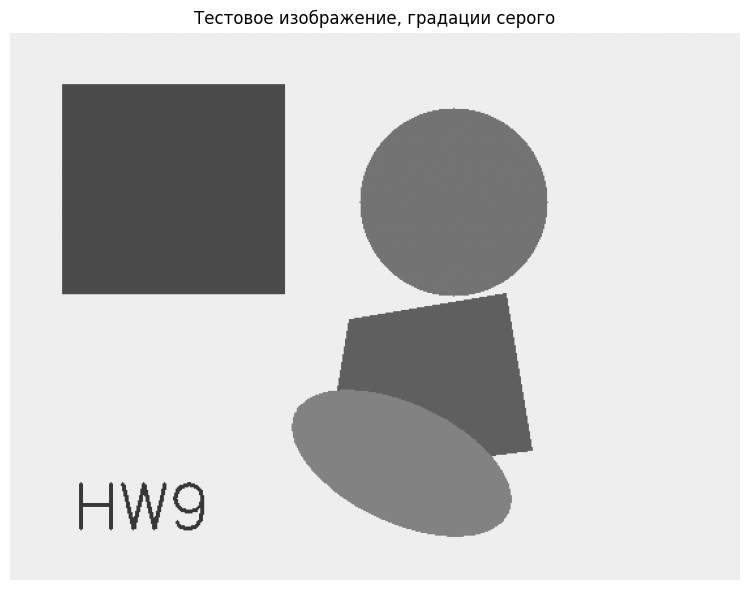

In [3]:
plt.figure(figsize=(8, 6))
plt.imshow(gray, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
plt.title("Тестовое изображение, градации серого")
plt.tight_layout()
plt.show()

## Задание 2

Найти все контуры на изображении с помощью cv.findContours.

In [4]:
_, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
contours, hierarchy = cv2.findContours(
    binary, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE
)

## Задание 3

Построить изображение всех контуров с помощью cv.drawContours.

In [5]:
all_contours_bgr = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
cv2.drawContours(all_contours_bgr, contours, -1, (0, 200, 0), 2)

array([[[238, 238, 238],
        [238, 238, 238],
        [238, 238, 238],
        ...,
        [238, 238, 238],
        [238, 238, 238],
        [238, 238, 238]],

       [[238, 238, 238],
        [238, 238, 238],
        [238, 238, 238],
        ...,
        [238, 238, 238],
        [238, 238, 238],
        [238, 238, 238]],

       [[238, 238, 238],
        [238, 238, 238],
        [238, 238, 238],
        ...,
        [238, 238, 238],
        [238, 238, 238],
        [238, 238, 238]],

       ...,

       [[238, 238, 238],
        [238, 238, 238],
        [238, 238, 238],
        ...,
        [238, 238, 238],
        [238, 238, 238],
        [238, 238, 238]],

       [[238, 238, 238],
        [238, 238, 238],
        [238, 238, 238],
        ...,
        [238, 238, 238],
        [238, 238, 238],
        [238, 238, 238]],

       [[238, 238, 238],
        [238, 238, 238],
        [238, 238, 238],
        ...,
        [238, 238, 238],
        [238, 238, 238],
        [238, 238, 238]]

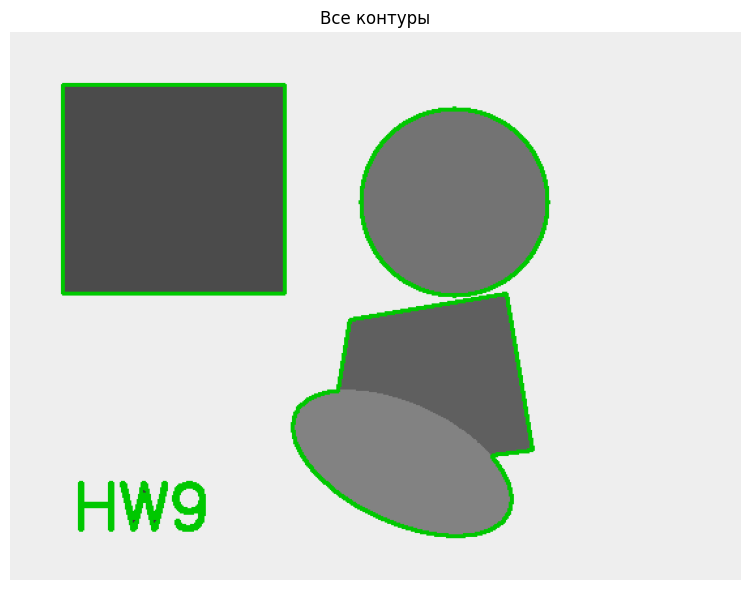

In [6]:
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(all_contours_bgr, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Все контуры")
plt.tight_layout()
plt.show()

## Задание 4

Вывести количество точек в трёх самых больших контурах.

In [7]:
contours_by_area = sorted(contours, key=cv2.contourArea, reverse=True)
top3 = contours_by_area[:3]
for i, c in enumerate(top3, start=1):
    print(f"Контур {i} (по площади): число точек = {len(c)}")

Контур 1 (по площади): число точек = 4
Контур 2 (по площади): число точек = 262
Контур 3 (по площади): число точек = 212


## Задание 5

На том же изображении построить выпуклую оболочку с помощью cv.convexHull для самого большого контура.

In [8]:
largest = contours_by_area[0]
hull_pts = cv2.convexHull(largest)
hull_bgr = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
cv2.drawContours(hull_bgr, [largest], -1, (0, 200, 0), 2)
cv2.drawContours(hull_bgr, [hull_pts], -1, (255, 0, 0), 2)

array([[[238, 238, 238],
        [238, 238, 238],
        [238, 238, 238],
        ...,
        [238, 238, 238],
        [238, 238, 238],
        [238, 238, 238]],

       [[238, 238, 238],
        [238, 238, 238],
        [238, 238, 238],
        ...,
        [238, 238, 238],
        [238, 238, 238],
        [238, 238, 238]],

       [[238, 238, 238],
        [238, 238, 238],
        [238, 238, 238],
        ...,
        [238, 238, 238],
        [238, 238, 238],
        [238, 238, 238]],

       ...,

       [[238, 238, 238],
        [238, 238, 238],
        [238, 238, 238],
        ...,
        [238, 238, 238],
        [238, 238, 238],
        [238, 238, 238]],

       [[238, 238, 238],
        [238, 238, 238],
        [238, 238, 238],
        ...,
        [238, 238, 238],
        [238, 238, 238],
        [238, 238, 238]],

       [[238, 238, 238],
        [238, 238, 238],
        [238, 238, 238],
        ...,
        [238, 238, 238],
        [238, 238, 238],
        [238, 238, 238]]

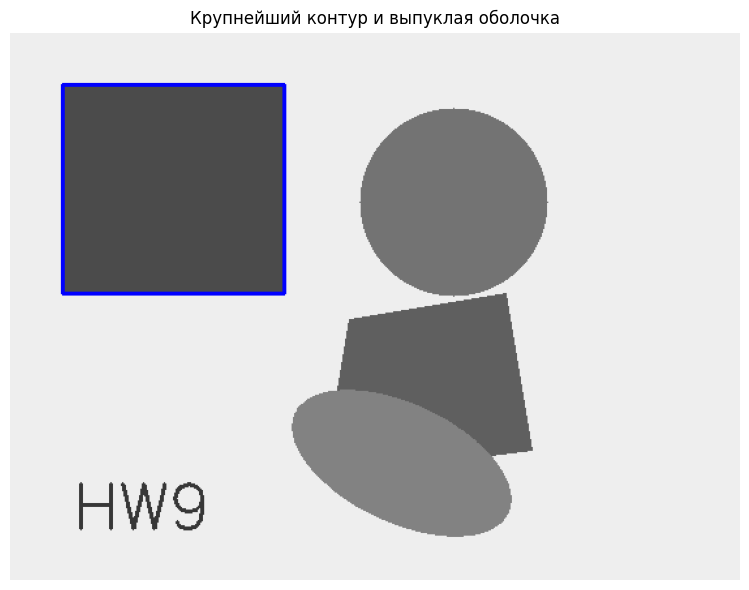

In [9]:
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(hull_bgr, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Крупнейший контур и выпуклая оболочка")
plt.tight_layout()
plt.show()

## Задание 6

Построить точки начала и конца каждого дефицита выпуклости (cv.convexityDefects).

In [10]:
defects_bgr = hull_bgr.copy()
hull_idx = cv2.convexHull(largest, returnPoints=False)
if hull_idx is not None and len(hull_idx) > 3:
    defects = cv2.convexityDefects(largest, hull_idx)
    if defects is not None:
        for j in range(defects.shape[0]):
            s, e, _, _ = defects[j, 0]
            p0 = tuple(largest[s][0])
            p1 = tuple(largest[e][0])
            cv2.circle(defects_bgr, p0, 5, (0, 0, 255), -1)
            cv2.circle(defects_bgr, p1, 5, (0, 255, 255), -1)

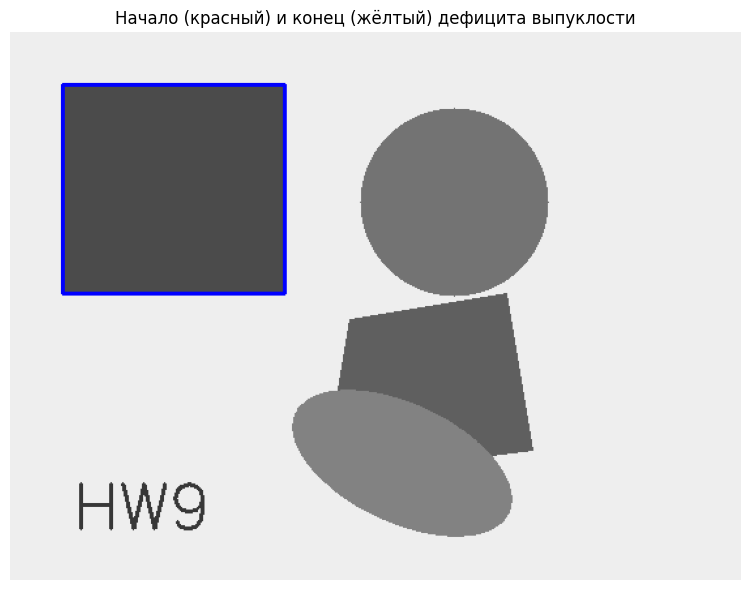

In [11]:
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(defects_bgr, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Начало (красный) и конец (жёлтый) дефицита выпуклости")
plt.tight_layout()
plt.show()

## Задание 7

Повторить построение для каждого метода аппроксимации в cv.findContours.

In [12]:
chain_methods = [
    (cv2.CHAIN_APPROX_NONE, "CHAIN_APPROX_NONE"),
    (cv2.CHAIN_APPROX_SIMPLE, "CHAIN_APPROX_SIMPLE"),
    (cv2.CHAIN_APPROX_TC89_L1, "CHAIN_APPROX_TC89_L1"),
    (cv2.CHAIN_APPROX_TC89_KCOS, "CHAIN_APPROX_TC89_KCOS"),
]
method_images = []
method_titles = []
for method, name in chain_methods:
    ctrs, _ = cv2.findContours(binary, cv2.RETR_LIST, method)
    if not ctrs:
        out = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
        method_images.append(out)
        method_titles.append(name)
        continue
    ctrs_sorted = sorted(ctrs, key=cv2.contourArea, reverse=True)
    cnt0 = ctrs_sorted[0]
    out = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
    cv2.drawContours(out, ctrs, -1, (0, 200, 0), 2)
    hull0 = cv2.convexHull(cnt0)
    cv2.drawContours(out, [cnt0], -1, (0, 160, 0), 2)
    cv2.drawContours(out, [hull0], -1, (255, 0, 0), 2)
    hidx = cv2.convexHull(cnt0, returnPoints=False)
    if hidx is not None and len(hidx) > 3:
        defc = cv2.convexityDefects(cnt0, hidx)
        if defc is not None:
            for j in range(defc.shape[0]):
                s, e, _, _ = defc[j, 0]
                p0 = tuple(cnt0[s][0])
                p1 = tuple(cnt0[e][0])
                cv2.circle(out, p0, 5, (0, 0, 255), -1)
                cv2.circle(out, p1, 5, (0, 255, 255), -1)
    method_images.append(out)
    method_titles.append(name)

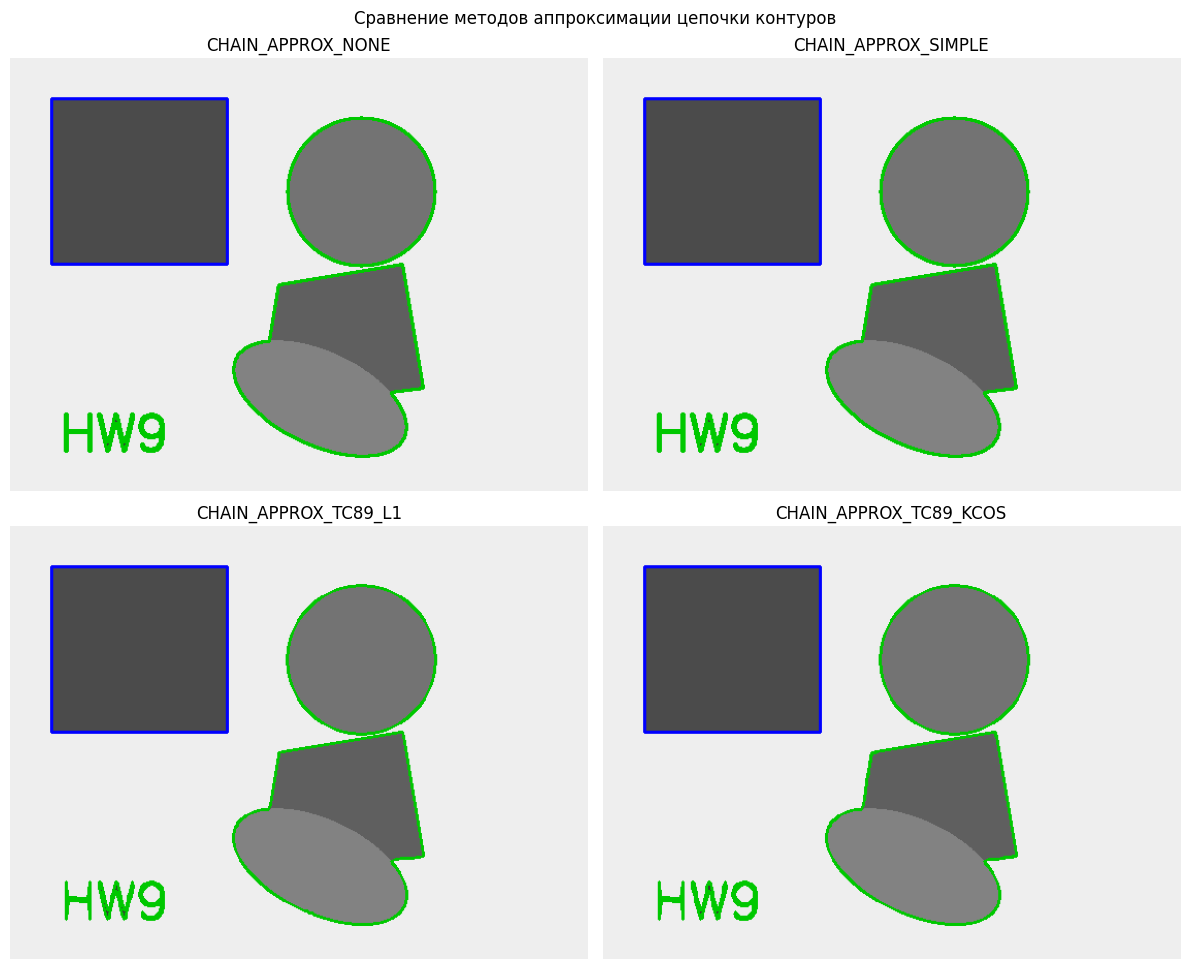

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()
for ax, img_bgr, title in zip(axes, method_images, method_titles):
    ax.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis("off")
plt.suptitle("Сравнение методов аппроксимации цепочки контуров")
plt.tight_layout()
plt.show()

### Выполнил: Мелешенко Николай